In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Load Dataset

df = pd.read_csv("HousePricePrediction.csv")

df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [5]:
# Check the shape of the dataset

print("Rows and Columns:", df.shape)

Rows and Columns: (2919, 13)


In [6]:
# Check column names

print(df.columns)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2',
       'TotalBsmtSF', 'SalePrice'],
      dtype='str')


In [7]:
# Get basic information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   str    
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   str    
 5   BldgType      2919 non-null   str    
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   str    
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), str(4)
memory usage: 296.6 KB


In [8]:
# Statistical summary

df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


## Data Cleaning

In [9]:
# Check missing values

df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [10]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

In [11]:
# Check data types

df.dtypes

Id                int64
MSSubClass        int64
MSZoning            str
LotArea           int64
LotConfig           str
BldgType            str
OverallCond       int64
YearBuilt         int64
YearRemodAdd      int64
Exterior1st         str
BsmtFinSF2      float64
TotalBsmtSF     float64
SalePrice       float64
dtype: object

In [14]:
# Drop Id as it doesn't contribute in price
df.drop(['Id'],
             axis=1,
             inplace=True)

In [12]:
# Remove rows where SalePrice is missing

df = df.dropna(subset=['SalePrice'])

print("Shape after removing missing SalePrice:", df.shape)

Shape after removing missing SalePrice: (1460, 13)


In [13]:
df.isnull().sum()

Id              0
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [15]:
# Correlation with SalePrice

correlation = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

print(correlation)

SalePrice       1.000000
TotalBsmtSF     0.613581
YearBuilt       0.522897
YearRemodAdd    0.507101
LotArea         0.263843
BsmtFinSF2     -0.011378
OverallCond    -0.077856
MSSubClass     -0.084284
Name: SalePrice, dtype: float64


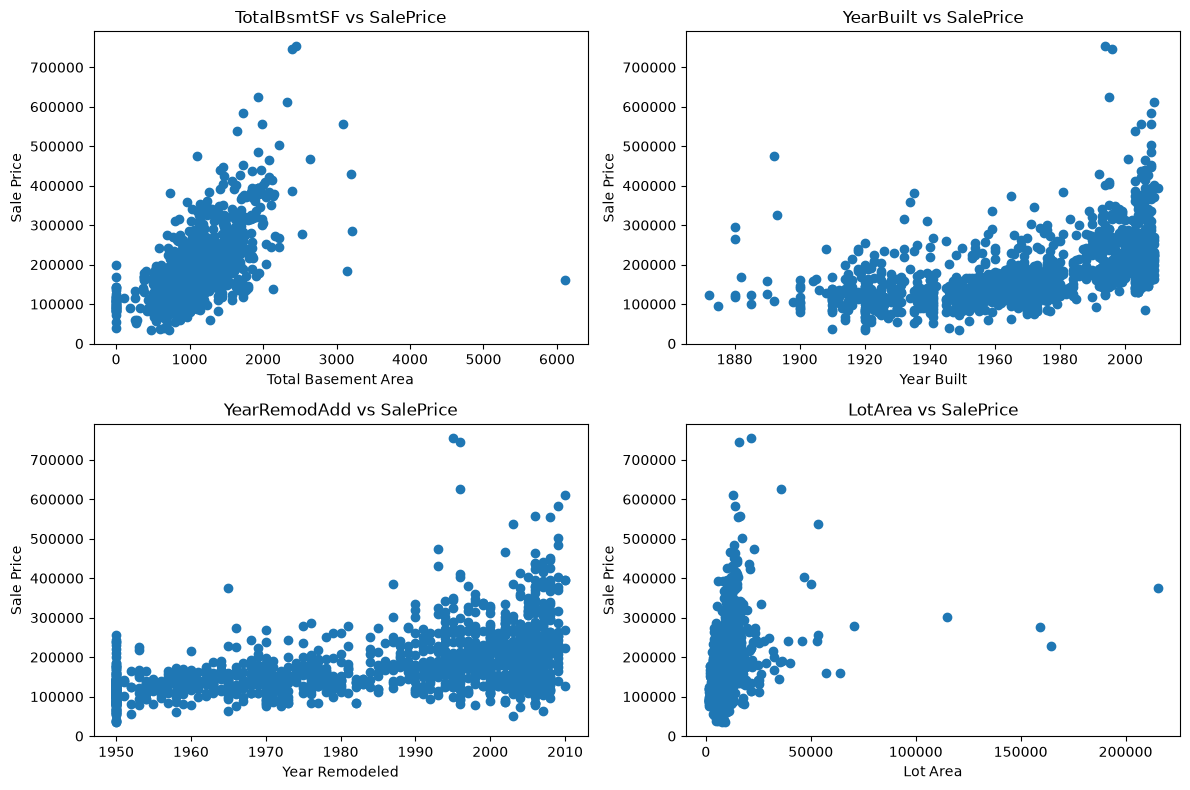

In [16]:
# Relationship between features and SalePrice

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.scatter(df['TotalBsmtSF'], df['SalePrice'])
plt.xlabel('Total Basement Area')
plt.ylabel('Sale Price')
plt.title('TotalBsmtSF vs SalePrice')

plt.subplot(2, 2, 2)
plt.scatter(df['YearBuilt'], df['SalePrice'])
plt.xlabel('Year Built')
plt.ylabel('Sale Price')
plt.title('YearBuilt vs SalePrice')

plt.subplot(2, 2, 3)
plt.scatter(df['YearRemodAdd'], df['SalePrice'])
plt.xlabel('Year Remodeled')
plt.ylabel('Sale Price')
plt.title('YearRemodAdd vs SalePrice')

plt.subplot(2, 2, 4)
plt.scatter(df['LotArea'], df['SalePrice'])
plt.xlabel('Lot Area')
plt.ylabel('Sale Price')
plt.title('LotArea vs SalePrice')

plt.tight_layout()
plt.show()

In [17]:
# Select features and target

X = df[['TotalBsmtSF', 'YearBuilt', 'YearRemodAdd', 'LotArea']]
y = df['SalePrice']

print("Features:", X.columns.tolist())
print("Target: SalePrice")

Features: ['TotalBsmtSF', 'YearBuilt', 'YearRemodAdd', 'LotArea']
Target: SalePrice


In [18]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1168, 4)
Testing data: (292, 4)


In [20]:
# Create and train Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 70.44, 491.83,1027.32, 1.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['TotalBsmtSF','YearBuilt','YearRemodAdd','LotArea']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.914e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [21]:
# Make predictions on test data

y_pred = model.predict(X_test)

print("Predictions made successfully!")
print(y_pred[:10])

Predictions made successfully!
[193420.32097216 233137.64399842 118275.05775036 123469.79345611
 264653.03285801 128157.27236531 174290.7264232  153990.61309197
 125608.92994413 131922.01646361]


In [22]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 37880.065399456296
Mean Squared Error (MSE): 3305725582.1875925
Root Mean Squared Error (RMSE): 57495.43966426896
R² Score: 0.5690241206312563


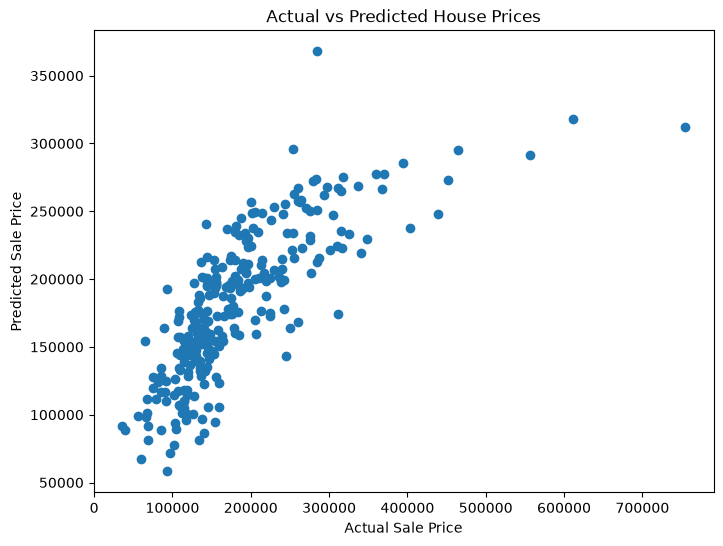

In [23]:
# Actual vs Predicted Prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [24]:
# Check model coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)
print("\nIntercept:", model.intercept_)

        Feature  Coefficient
0   TotalBsmtSF    70.443289
1     YearBuilt   491.828050
2  YearRemodAdd  1027.320838
3       LotArea     1.101023

Intercept: -2913625.231264993


In [32]:
# Test the model with a new house

new_house = pd.DataFrame({
    'TotalBsmtSF': [1000],
    'YearBuilt': [2005],
    'YearRemodAdd': [2005],
    'LotArea': [8000]
})

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 211519.7630509967


In [33]:
# Compare Actual vs Predicted prices

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison['Difference'] = (
    comparison['Actual Price'] - comparison['Predicted Price']
)

print(comparison.head(10))

   Actual Price  Predicted Price     Difference
0      154500.0    193420.320972  -38920.320972
1      325000.0    233137.643998   91862.356002
2      115000.0    118275.057750   -3275.057750
3      159000.0    123469.793456   35530.206544
4      315500.0    264653.032858   50846.967142
5       75500.0    128157.272365  -52657.272365
6      311500.0    174290.726423  137209.273577
7      146000.0    153990.613092   -7990.613092
8       84500.0    125608.929944  -41108.929944
9      135500.0    131922.016464    3577.983536


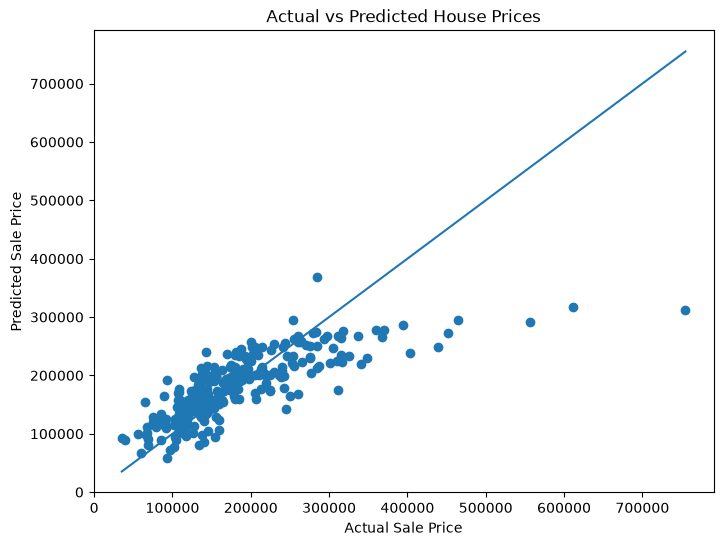

In [34]:
# Actual vs Predicted Prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [35]:
# Conclusion

print("House Price Prediction using Linear Regression")
print("-----------------------------------------------")
print("Model: Linear Regression")
print("Features: TotalBsmtSF, YearBuilt, YearRemodAdd, LotArea")
print(f"R² Score: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

House Price Prediction using Linear Regression
-----------------------------------------------
Model: Linear Regression
Features: TotalBsmtSF, YearBuilt, YearRemodAdd, LotArea
R² Score: 0.569
MAE: 37880.07
RMSE: 57495.44
